
# 🧠 Semaine 2 · Jour 4 — Gestion de dialogue & session (Conversation State)

Ce notebook explore les concepts clés de la **gestion de dialogue** et de **session** pour les grands modèles de langage (LLM).


## 📘 Partie 1 — Théorie : Pourquoi limiter le contexte ?

### Pourquoi les LLM n’ont pas de mémoire native
Les LLM sont des modèles **stateless** : ils génèrent des réponses en se basant uniquement sur :
- L’entrée actuelle.
- Leurs poids pré-entraînés.

**Problème** : Sans gestion explicite, chaque interaction est isolée, ce qui limite la cohérence des dialogues sur plusieurs tours.


### Limites de la fenêtre de contexte
- **Taille limitée** : Fenêtre maximale (ex. : 4K, 8K, 32K tokens).
- **Coût élevé** : Plus la fenêtre est grande, plus les coûts computationnels et financiers augmentent.
- **Oubli** : Les informations hors fenêtre sont perdues, sauf si stockées externement.

**Solutions :**
1. Conserver une mémoire courte (fenêtre glissante).
2. Résumer les anciens échanges.
3. Séparer les sessions (par utilisateur ou sujet).

---
### Différences entre les types de mémoire

| **Type**               | **Description**                                      | **Durée**      | **Exemple d’utilisation**          |
|------------------------|------------------------------------------------------|----------------|------------------------------------|
| Mémoire courte         | Stockée dans la fenêtre de contexte actuelle.        | Éphémère       | Dialogue en temps réel             |
| État de session        | Maintenu pendant une session utilisateur.           | Session        | Suivi de conversation              |
| Mémoire longue         | Stockage persistant entre les sessions.              | Permanente     | Historique utilisateur, préférences|
| Fenêtrage de contexte  | Technique pour gérer la taille de la fenêtre.        | Dynamique      | Limiter aux *N* derniers échanges   |

---

---
### Schéma global de l’architecture mémoire

```mermaid
graph TD
    A[Utilisateur] -->|Requête| B[Agent Conversationnel]
    B --> C[Mémoire Courte]
    B --> D[État de Session]
    B --> E[Mémoire Longue]
    C -->|Contexte immédiat| B
    D -->|État session| B
    E -->|Historique| B
    B -->|Réponse| A
```

---
L’agent doit gérer le * glissement de la fenêtre de contexte* et la *synchronisation entre ces mémoires *.

👉 Les systèmes modernes (LangChain, LlamaIndex, OpenAI MCP) combinent ces trois approches pour créer des agents cohérents, persistants et scalables.

## **2. Visualisation**

### Glissement de fenêtre

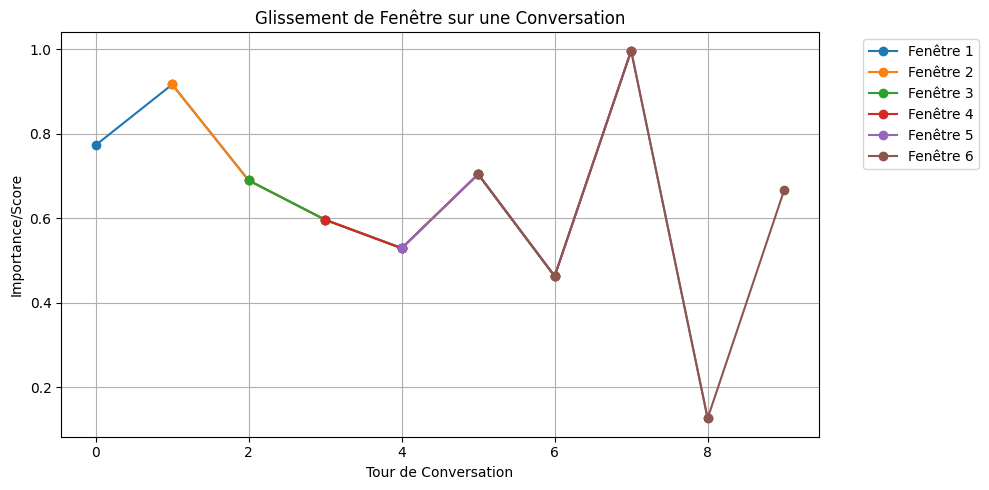

In [2]:
import matplotlib.pyplot as plt
import numpy as np

window_size = 5
conversation_length = 10
x = np.arange(conversation_length)
y = np.random.rand(conversation_length)

plt.figure(figsize=(10, 5))
for i in range(conversation_length - window_size + 1):
    plt.plot(x[i:i+window_size], y[i:i+window_size], marker='o', label=f'Fenêtre {i+1}')

plt.title("Glissement de Fenêtre sur une Conversation")
plt.xlabel("Tour de Conversation")
plt.ylabel("Importance/Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig('sliding_window.png', format='PNG', dpi=200, bbox_inches='tight')
plt.show()


### Comparaison des approches

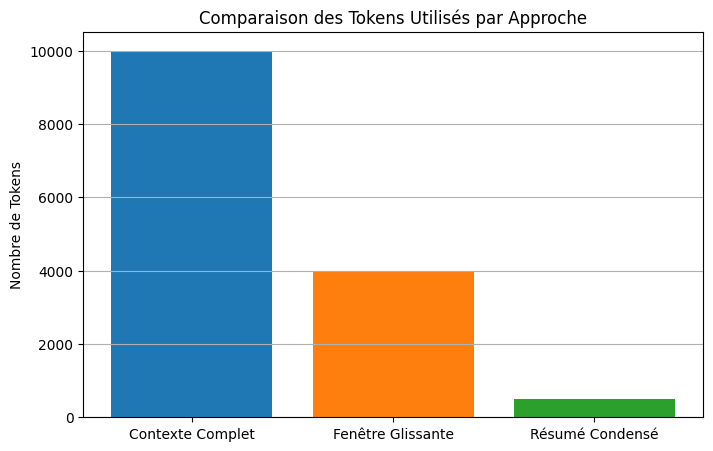

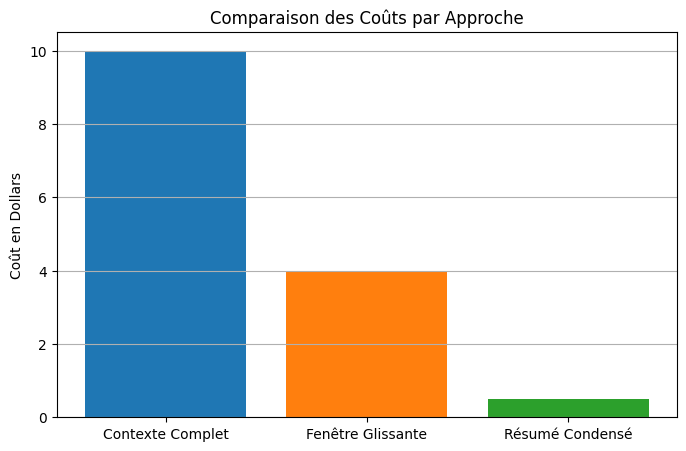

In [3]:
approaches = ['Contexte Complet', 'Fenêtre Glissante', 'Résumé Condensé']
tokens_used = [10000, 4000, 500]
cost = [10.0, 4.0, 0.5]

# Tokens utilisés
plt.figure(figsize=(8, 5))
plt.bar(approaches, tokens_used, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Comparaison des Tokens Utilisés par Approche")
plt.ylabel("Nombre de Tokens")
plt.grid(True, axis='y')
plt.savefig('tokens_comparison.png', format='PNG', dpi=200, bbox_inches='tight')
plt.show()

# Coûts
plt.figure(figsize=(8, 5))
plt.bar(approaches, cost, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Comparaison des Coûts par Approche")
plt.ylabel("Coût en Dollars")
plt.grid(True, axis='y')
plt.savefig('cost_comparison.png', format='PNG', dpi=200, bbox_inches='tight')
plt.show()

## **3. Implémentation en Python**

### Mémoire à Court Terme

In [5]:
class ShortTermMemory:
    def __init__(self, max_tokens=4000):
        self.max_tokens = max_tokens
        self.buffer = []

    def add(self, message):
        self.buffer.append(message)
        if self._count_tokens(self.buffer) > self.max_tokens:
            self.buffer.pop(0)

    def _count_tokens(self, messages):
        return sum(len(msg) // 4 for msg in messages)

    def get_context(self):
        return self.buffer

## État de Session

In [6]:
class SessionState:
    def __init__(self):
        self.state = {}

    def update(self, key, value):
        self.state[key] = value

    def get(self, key):
        return self.state.get(key)

    def clear(self):
        self.state = {}

### Mémoire à Long Terme

In [ ]:
import json
import os

class LongTermMemory:
    def __init__(self, storage_file='long_term_memory.json'):
        self.storage_file = storage_file
        self.memory = self._load()

    def _load(self):
        if os.path.exists(self.storage_file):
            with open(self.storage_file, 'r') as f:
                return json.load(f)
        return {}

    def _save(self):
        with open(self.storage_file, 'w') as f:
            json.dump(self.memory, f, indent=4)

    def add(self, key, value):
        self.memory[key] = value
        self._save()

    def get(self, key):
        return self.memory.get(key)

    def clear(self):
        self.memory = {}
        self._save()

### Agent Conversationnel


In [ ]:
class ConversationalAgent:
    def __init__(self):
        self.short_term_memory = ShortTermMemory()
        self.session_state = SessionState()
        self.long_term_memory = LongTermMemory()

    def process_message(self, user_message):
        self.short_term_memory.add(user_message)
        context = self.short_term_memory.get_context()
        response = f"Réponse basée sur le contexte : {context}"
        self.short_term_memory.add(response)
        return response

    def save_session(self, session_id, data):
        self.session_state.update(session_id, data)

    def load_session(self, session_id):
        return self.session_state.get(session_id)

    def save_to_long_term(self, key, value):
        self.long_term_memory.add(key, value)

    def load_from_long_term(self, key):
        return self.long_term_memory.get(key)

### Simulation d’Utilisateur

In [ ]:
agent = ConversationalAgent()

# Échange 1
message_1 = "Bonjour, je m'appelle Steph."
response_1 = agent.process_message(message_1)

# Échange 2
message_2 = "J'ai un chien nommé Max."
response_2 = agent.process_message(message_2)

# Sauvegarde en mémoire longue
agent.save_to_long_term('utilisateur', {'nom': 'Steph', 'chien': 'Max'})
user_data = agent.load_from_long_term('utilisateur')

print("Réponse 1 :", response_1)
print("Réponse 2 :", response_2)
print("Données utilisateur en mémoire longue :", user_data)

## **4. Version OpenAI Réelle**

### Intégration avec l’API OpenAI

In [ ]:
from typing import List, Dict

class OpenAIAgent:
    def __init__(self, api_key: str, model: str = 'gpt-3.5-turbo'):
        self.api_key = api_key
        self.model = model
        self.messages: List[Dict[str, str]] = []
        self.max_tokens = 4000

    def add_message(self, role: str, content: str):
        self.messages.append({'role': role, 'content': content})
        if self._count_tokens(self.messages) > self.max_tokens:
            self._summarize_if_needed()

    def _count_tokens(self, messages: List[Dict[str, str]]) -> int:
        return sum(len(msg['content']) // 4 for msg in messages)

    def _summarize_if_needed(self):
        if len(self.messages) > 10:
            summary = {'role': 'system', 'content': 'Résumé des messages précédents...'}
            self.messages = [summary] + self.messages[-5:]

    def get_context(self) -> List[Dict[str, str]]:
        return self.messages

---
---
## **5. Exercices Pratiques**

1. **Remplacer JSON par SQLite** : Modifier `LongTermMemory` pour utiliser SQLite.
2. **Ajouter une mémoire vectorielle** : Intégrer FAISS ou Chroma pour stocker des *embeddings*.
3. **Résumé automatique avec GPT** : Utiliser l’API OpenAI pour résumer les messages quand la limite de tokens est dépassée.
4. **Mesurer les coûts** : Ajouter une fonction pour estimer le coût en tokens et en argent par requête.

---
---
## **6. Notes pour le Formateur**

### Comparaison des Frameworks

| **Framework**   | **Mémoire Courte**       | **Session**          | **Mémoire Longue**     |
|-----------------|--------------------------|----------------------|------------------------|
| OpenAI API      | `messages[]`             | Code Python          | Base de données externe|
| LangChain       | `ConversationBuffer`     | `session store`      | `VectorStore`         |
| LlamaIndex      | `ChatMemoryBuffer`       | `state`              | `Index`                |
| MCP             | Contexte outil           | État serveur         | Stockage externe       |

## 💻 Partie 2 — Implémentation Python pure (mode mock)

In [ ]:

from collections import deque

class ConversationManager:
    def __init__(self, window_size=5):
        self.messages = deque(maxlen=window_size)
    
    def add_message(self, role, content):
        self.messages.append({"role": role, "content": content})
    
    def get_context(self):
        return list(self.messages)
    
    def summarize_context(self):
        summary = "Résumé: " + " | ".join([m["content"] for m in list(self.messages)[:-1]])
        return summary

# Test mock conversation
conv = ConversationManager(window_size=3)
conv.add_message("user", "Bonjour, peux-tu m'aider ?")
conv.add_message("assistant", "Oui, bien sûr ! Quel est ton problème ?")
conv.add_message("user", "Je veux comprendre la gestion de contexte.")
conv.add_message("assistant", "Parfait, parlons-en !")

conv.get_context()


In [ ]:

# Résumé automatique simulé
conv.summarize_context()


## 🤖 Partie 3 — Mode OpenAI réel (optionnel)

In [ ]:

# ⚠️ Nécessite une clé API OpenAI valide dans les variables d’environnement
# import os
# from openai import OpenAI
# client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# def ask_with_context(manager, user_input):
#     manager.add_message("user", user_input)
#     response = client.chat.completions.create(
#         model="gpt-4o-mini",
#         messages=manager.get_context()
#     )
#     answer = response.choices[0].message.content
#     manager.add_message("assistant", answer)
#     return answer

# Exemple :
# ask_with_context(conv, "Explique-moi la mémoire courte.")



## 🧠 Partie 4 — Exercices pratiques

1. 🔁 Implémente une **mémoire qui s’efface** après N tours.  
2. 🧩 Crée une fonction `summarize_context()` qui appelle GPT pour condenser l’historique.  
3. ⚖️ Compare le coût d’appels API selon la taille du contexte.

💡 *Astuce : teste tes fonctions en mode mock avant d’utiliser la vraie API.*



## 🔗 Ressources utiles
- [OpenAI API — Chat Completions](https://platform.openai.com/docs/guides/text-generation)
- [LangChain — Memory Concepts](https://python.langchain.com/docs/modules/memory/)
- [AssemblyAI — Context Windows](https://www.youtube.com/watch?v=x_VhNpYpu8E)
- [Hugging Face Agents — ConversationBufferMemory](https://huggingface.co/docs/transformers/transformers_agents)
